# Smart Air Conditioning Control Using Fuzzy Logic

This project implements a Mamdani Fuzzy Logic Controller for intelligent air conditioning power management.

## Inputs
- Temperature (°C)
- Humidity (%)

## Output
- AC Power (%)

The controller uses fuzzy membership functions and inference rules to determine the appropriate cooling power based on environmental conditions.

In [195]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import skfuzzy as fuzz
from skfuzzy import control as ctrl

import matplotlib.pyplot as plt

## Dataset Loading and Exploration

The dataset contains environmental sensor readings collected over a 3-hour period, including temperature and humidity measurements.

In [196]:
df = pd.read_csv("data_3hrs.csv", encoding="latin1")

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (5400, 4)
   Timestamp (ms)  Humidity (%)  Temperature (°F)  Temperature (°C)
0               0         43.70             76.64             24.80
1            2000         45.26             76.56             24.76
2            4000         44.97             76.70             24.83
3            6000         45.96             78.22             25.68
4            8000         46.24             78.51             25.84


In [197]:
df[['Temperature (°C)', 'Humidity (%)']].describe()

,Temperature (°C),Humidity (%)
count,5400.000000,5400.000000
mean,25.043541,45.010431
std,0.683881,1.491107
min,23.280000,40.000000
25%,24.670000,44.020000
50%,25.020000,45.010000
75%,25.360000,45.992500
max,35.220000,50.000000


## Fuzzy Variables and Membership Functions

Three fuzzy variables are defined:

1. Temperature
2. Humidity
3. AC Power

Each variable is represented using linguistic terms and fuzzy membership functions.

In [198]:
temperature = ctrl.Antecedent(
    np.arange(23, 36, 0.1),
    'temperature'
)

humidity = ctrl.Antecedent(
    np.arange(40, 51, 0.1),
    'humidity'
)

ac_power = ctrl.Consequent(
    np.arange(0, 101, 1),
    'ac_power'
)

In [199]:
temperature['cool'] = fuzz.trapmf(
    temperature.universe, [23, 23, 24, 25.5])

temperature['comfortable'] = fuzz.trimf(
    temperature.universe, [24.5, 25.5, 27])

temperature['hot'] = fuzz.trapmf(
    temperature.universe, [26, 30, 35.5, 35.5])

### Temperature Membership Functions

c:\Users\ahmed\AppData\Local\Programs\Python\Python310\lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


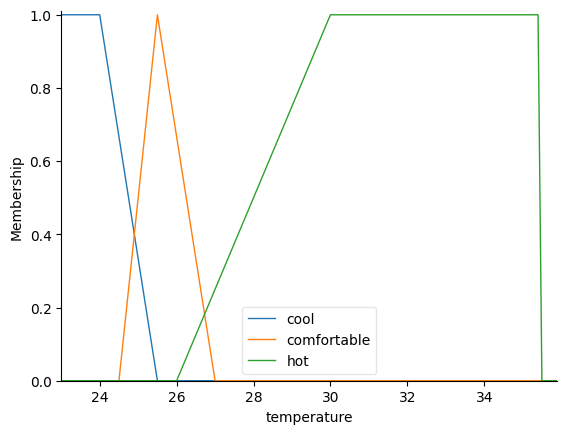

In [200]:
temperature.view()

plt.show()

In [201]:
humidity['low'] = fuzz.trapmf(
    humidity.universe, [40, 40, 42, 45])

humidity['medium'] = fuzz.trimf(
    humidity.universe, [43, 45, 47])

humidity['high'] = fuzz.trapmf(
    humidity.universe, [45, 48, 50, 50])

### Humidity Membership Functions

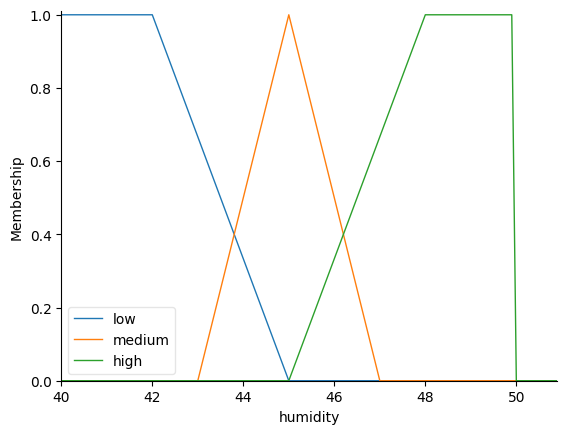

In [202]:
humidity.view()

plt.show()

In [203]:
ac_power['low'] = fuzz.trimf(
    ac_power.universe, [0, 0, 40])

ac_power['medium'] = fuzz.trimf(
    ac_power.universe, [20, 50, 80])

ac_power['high'] = fuzz.trimf(
    ac_power.universe, [60, 100, 100])

### AC Power Membership Functions

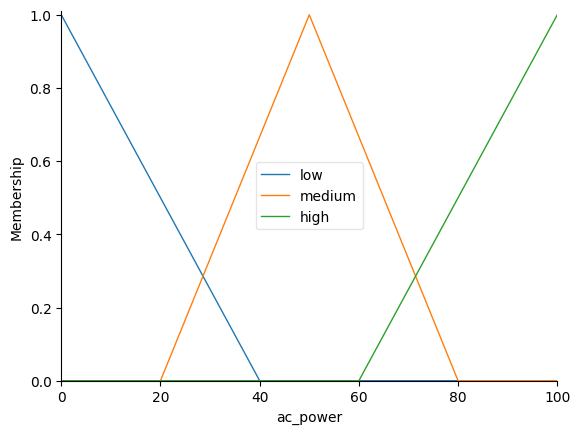

In [204]:
ac_power.view()
plt.show()

## Fuzzy Rule Base

The controller uses nine fuzzy inference rules to determine the required AC power level based on temperature and humidity conditions.

In [205]:
rule1 = ctrl.Rule(
    temperature['cool'] & humidity['low'],
    ac_power['low'])

rule2 = ctrl.Rule(
    temperature['cool'] & humidity['medium'],
    ac_power['low'])

rule3 = ctrl.Rule(
    temperature['cool'] & humidity['high'],
    ac_power['medium'])

rule4 = ctrl.Rule(
    temperature['comfortable'] & humidity['low'],
    ac_power['medium'])

rule5 = ctrl.Rule(
    temperature['comfortable'] & humidity['medium'],
    ac_power['medium'])

rule6 = ctrl.Rule(
    temperature['comfortable'] & humidity['high'],
    ac_power['high'])

rule7 = ctrl.Rule(
    temperature['hot'] & humidity['low'],
    ac_power['high'])

rule8 = ctrl.Rule(
    temperature['hot'] & humidity['medium'],
    ac_power['high'])

rule9 = ctrl.Rule(
    temperature['hot'] & humidity['high'],
    ac_power['high'])

In [206]:
ac_ctrl = ctrl.ControlSystem([
    rule1, rule2, rule3,
    rule4, rule5, rule6,
    rule7, rule8, rule9
])

ac_sim = ctrl.ControlSystemSimulation(ac_ctrl)

In [207]:
for rule in ac_ctrl.rules:
    print(rule)

IF temperature[cool] AND humidity[low] THEN ac_power[low]
	AND aggregation function : fmin
	OR aggregation function  : fmax
IF temperature[cool] AND humidity[medium] THEN ac_power[low]
	AND aggregation function : fmin
	OR aggregation function  : fmax
IF temperature[cool] AND humidity[high] THEN ac_power[medium]
	AND aggregation function : fmin
	OR aggregation function  : fmax
IF temperature[comfortable] AND humidity[low] THEN ac_power[medium]
	AND aggregation function : fmin
	OR aggregation function  : fmax
IF temperature[comfortable] AND humidity[medium] THEN ac_power[medium]
	AND aggregation function : fmin
	OR aggregation function  : fmax
IF temperature[comfortable] AND humidity[high] THEN ac_power[high]
	AND aggregation function : fmin
	OR aggregation function  : fmax
IF temperature[hot] AND humidity[low] THEN ac_power[high]
	AND aggregation function : fmin
	OR aggregation function  : fmax
IF temperature[hot] AND humidity[medium] THEN ac_power[high]
	AND aggregation function : fmin

## Controller Validation

A sample input is used to verify that the fuzzy controller produces a valid AC power output.

In [208]:
ac_sim.input['temperature'] = 24.8
ac_sim.input['humidity'] = 43.7

ac_sim.compute()

print(ac_sim.output)

{'ac_power': np.float64(34.53976046484055)}


## Applying the Controller to the Dataset

The fuzzy controller is executed for all sensor readings and the resulting AC power values are stored in a new column.

In [209]:
ac_results = []

for _, row in df.iterrows():

    sim = ctrl.ControlSystemSimulation(ac_ctrl)

    sim.input['temperature'] = row['Temperature (°C)']
    sim.input['humidity'] = row['Humidity (%)']

    sim.compute()

    ac_results.append(sim.output['ac_power'])

df['AC Power (%)'] = ac_results

In [210]:
print(df[['Temperature (°C)',
          'Humidity (%)',
          'AC Power (%)']].head(10))

   Temperature (°C)  Humidity (%)  AC Power (%)
0             24.80         43.70     34.539760
1             24.76         45.26     36.137007
2             24.83         44.97     34.978515
3             25.68         45.96     59.565404
4             25.84         46.24     63.386382
5             25.39         42.71     47.954409
6             25.52         46.96     83.507205
7             24.83         44.17     34.978515
8             24.77         46.99     58.427765
9             24.93         44.94     38.082199


In [211]:
print(df['AC Power (%)'].describe())

count    5400.000000
mean       44.150435
std        15.762509
min        13.333333
25%        35.321314
50%        45.301965
75%        51.131035
max        86.664327
Name: AC Power (%), dtype: float64


## Results and Visualization

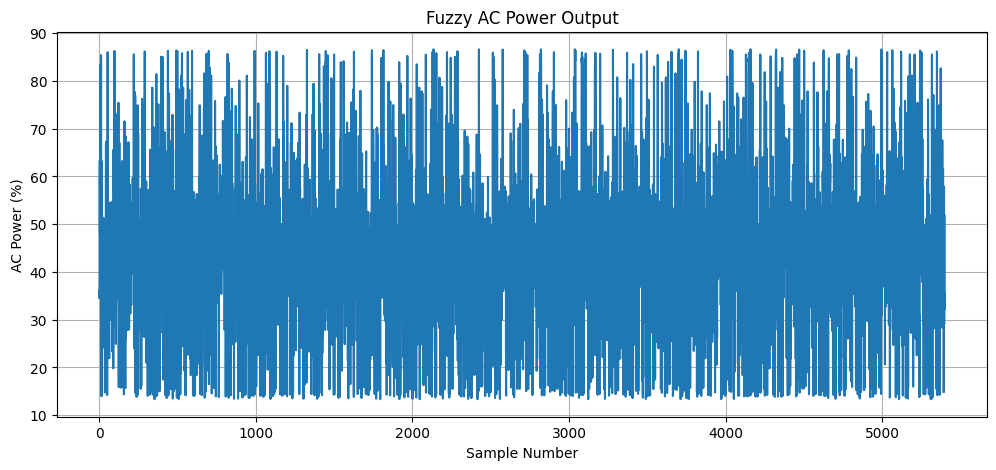

In [212]:
plt.figure(figsize=(12,5))

plt.plot(df['AC Power (%)'])

plt.title('Fuzzy AC Power Output')
plt.xlabel('Sample Number')
plt.ylabel('AC Power (%)')

plt.grid(True)
plt.show()

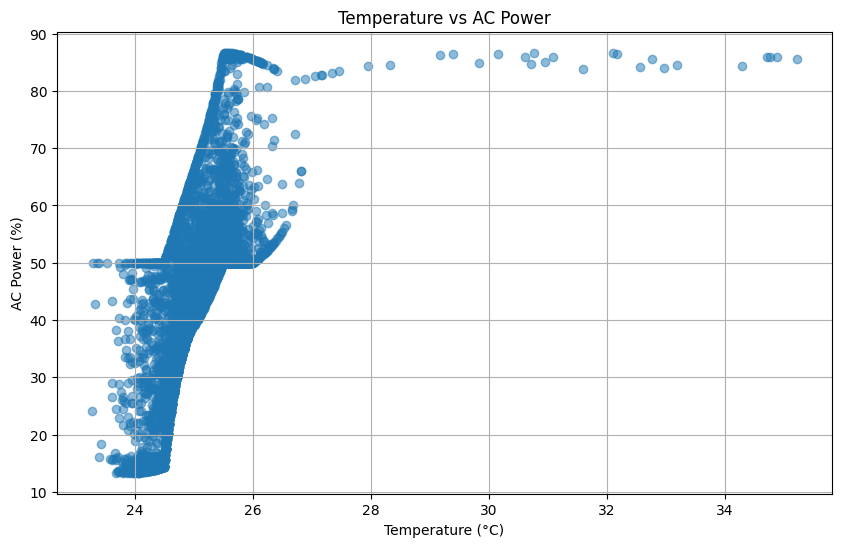

In [213]:
plt.figure(figsize=(10,6))

plt.scatter(
    df['Temperature (°C)'],
    df['AC Power (%)'],
    alpha=0.5
)

plt.xlabel('Temperature (°C)')
plt.ylabel('AC Power (%)')
plt.title('Temperature vs AC Power')

plt.grid(True)
plt.show()

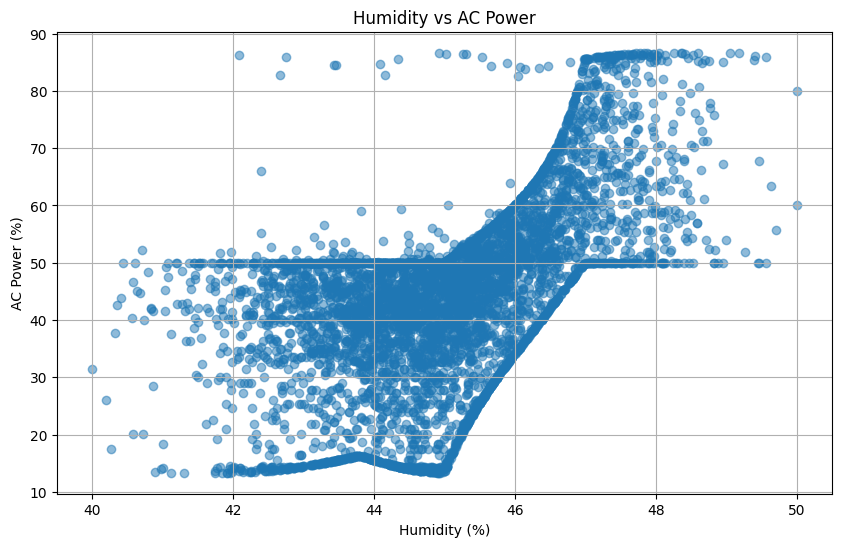

In [214]:
plt.figure(figsize=(10,6))

plt.scatter(
    df['Humidity (%)'], 
    df['AC Power (%)'],
    alpha=0.5
)

plt.xlabel('Humidity (%)')
plt.ylabel('AC Power (%)')
plt.title('Humidity vs AC Power')

plt.grid(True)
plt.show()

## Correlation Analysis

The correlation matrix is used to analyze the relationship between temperature, humidity, and the generated AC power output.

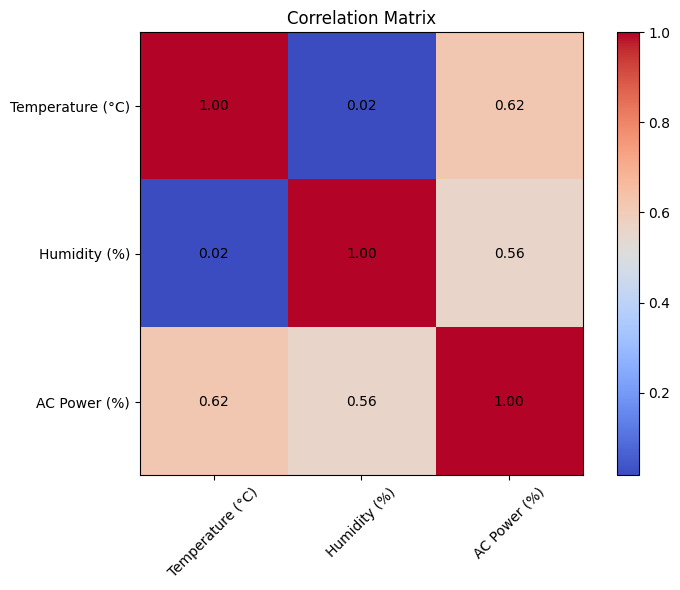

In [215]:
corr_matrix = df[['Temperature (°C)',
                  'Humidity (%)',
                  'AC Power (%)']].corr()

plt.figure(figsize=(8,6))

plt.imshow(corr_matrix, cmap='coolwarm', interpolation='nearest')

plt.colorbar()

plt.xticks(range(len(corr_matrix.columns)),
           corr_matrix.columns,
           rotation=45)

plt.yticks(range(len(corr_matrix.columns)),
           corr_matrix.columns)

for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        plt.text(j, i,
                 f"{corr_matrix.iloc[i,j]:.2f}",
                 ha='center',
                 va='center')

plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

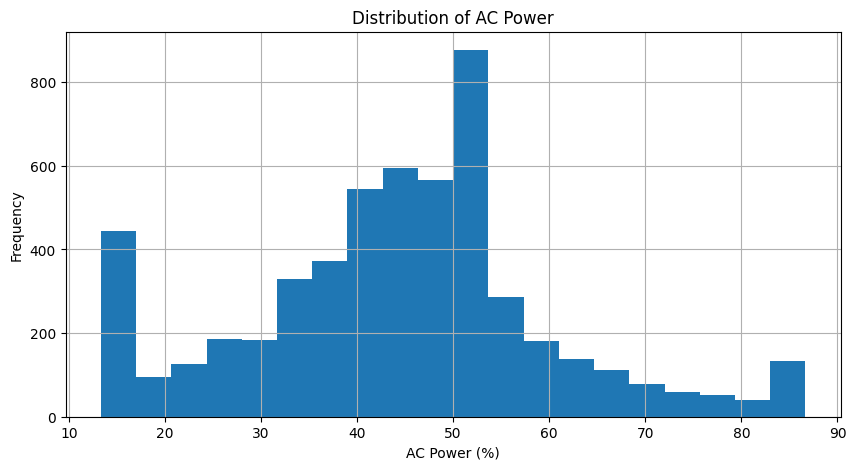

In [216]:
plt.figure(figsize=(10,5))

plt.hist(df['AC Power (%)'], bins=20)

plt.title('Distribution of AC Power')
plt.xlabel('AC Power (%)')
plt.ylabel('Frequency')

plt.grid(True)
plt.show()

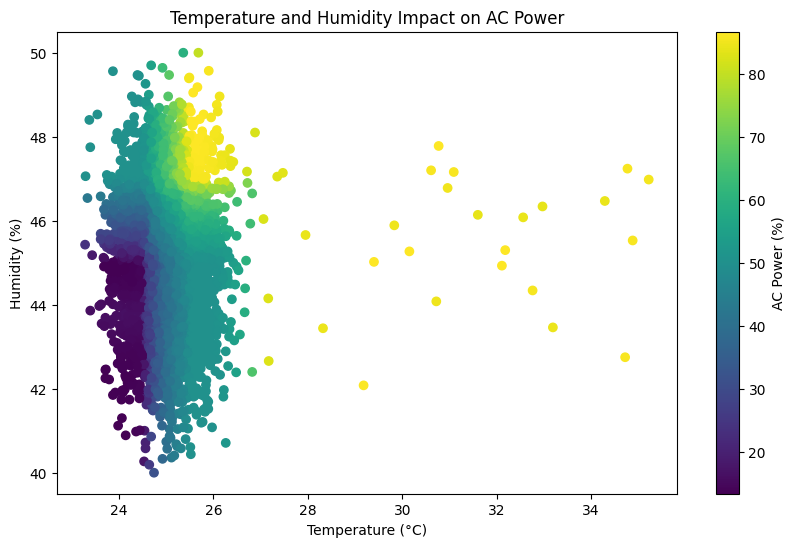

In [219]:
plt.figure(figsize=(10,6))

plt.scatter(
    df['Temperature (°C)'],
    df['Humidity (%)'],
    c=df['AC Power (%)']
)

plt.colorbar(label='AC Power (%)')

plt.xlabel('Temperature (°C)')
plt.ylabel('Humidity (%)')

plt.title('Temperature and Humidity Impact on AC Power')

plt.show()

## Exporting Results

The processed dataset containing the generated AC power values is exported for further analysis.

In [218]:
df.to_csv("fuzzy_ac_results.csv", index=False)